
--- Naive Bayes ---
Train Accuracy: 0.5648
Validation Accuracy: 0.5601
Test Accuracy: 0.5563
Macro F1 Score: 0.5106

--- Decision Tree ---
Train Accuracy: 1.0000
Validation Accuracy: 0.8692
Test Accuracy: 0.8763
Macro F1 Score: 0.8745

--- Random Forest ---
Train Accuracy: 1.0000
Validation Accuracy: 0.9693
Test Accuracy: 0.9687
Macro F1 Score: 0.9685

--- SVM ---
Train Accuracy: 0.9896
Validation Accuracy: 0.9776
Test Accuracy: 0.9777
Macro F1 Score: 0.9777

--- Logistic Regression ---
Train Accuracy: 0.9458
Validation Accuracy: 0.9147
Test Accuracy: 0.9167
Macro F1 Score: 0.9155

--- MLP ---
Train Accuracy: 1.0000
Validation Accuracy: 0.9787
Test Accuracy: 0.9788
Macro F1 Score: 0.9786

--- CNN ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


469/469 - 22s - 47ms/step - accuracy: 0.8277 - loss: 0.5374 - val_accuracy: 0.9801 - val_loss: 0.0631
Epoch 2/10
469/469 - 17s - 37ms/step - accuracy: 0.9360 - loss: 0.2103 - val_accuracy: 0.9863 - val_loss: 0.0405
Epoch 3/10
469/469 - 17s - 36ms/step - accuracy: 0.9531 - loss: 0.1568 - val_accuracy: 0.9881 - val_loss: 0.0333
Epoch 4/10
469/469 - 21s - 45ms/step - accuracy: 0.9603 - loss: 0.1309 - val_accuracy: 0.9904 - val_loss: 0.0286
Epoch 5/10
469/469 - 17s - 37ms/step - accuracy: 0.9655 - loss: 0.1142 - val_accuracy: 0.9896 - val_loss: 0.0289
Epoch 6/10
469/469 - 17s - 36ms/step - accuracy: 0.9698 - loss: 0.1056 - val_accuracy: 0.9915 - val_loss: 0.0248
Epoch 7/10
469/469 - 19s - 40ms/step - accuracy: 0.9728 - loss: 0.0946 - val_accuracy: 0.9922 - val_loss: 0.0250
Epoch 8/10
469/469 - 18s - 38ms/step - accuracy: 0.9740 - loss: 0.0858 - val_accuracy: 0.9929 - val_loss: 0.0222
Epoch 9/10
469/469 - 19s - 40ms/step - accuracy: 0.9759 - loss: 0.0800 - val_accuracy: 0.9931 - val_loss: 0

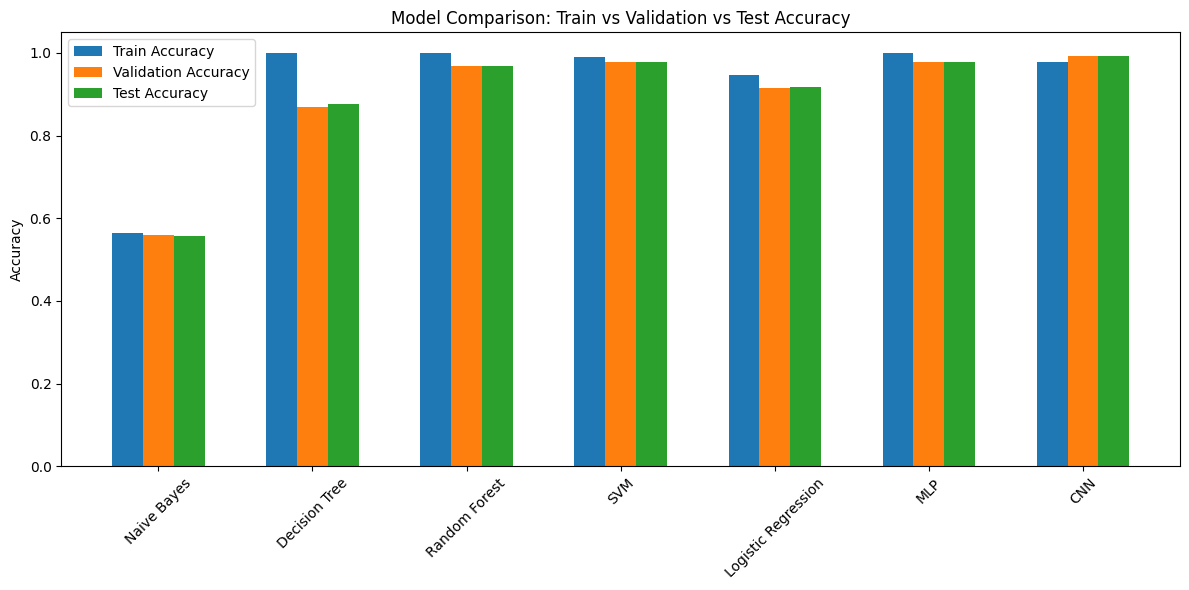

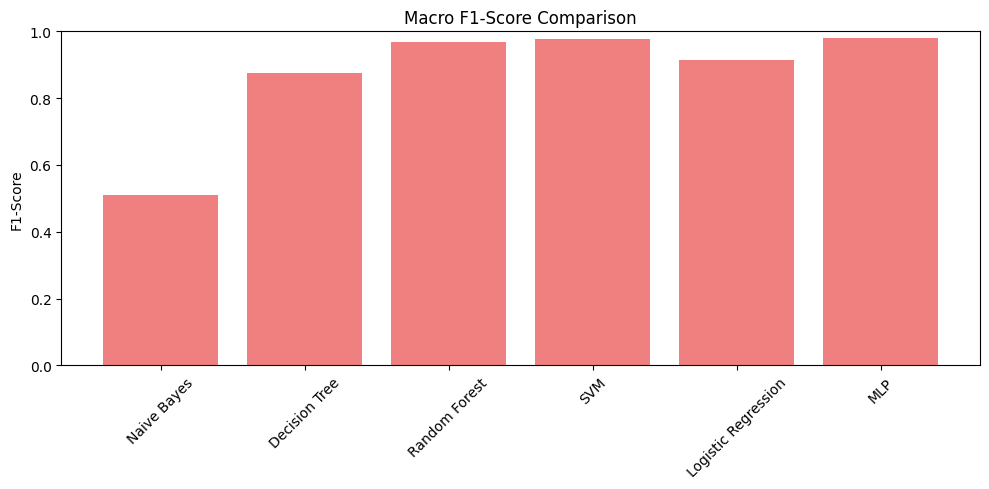

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_fscore_support
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load Data
(x_trainval, y_trainval), (x_test, y_test) = mnist.load_data()
x_trainval_flat = x_trainval.reshape((x_trainval.shape[0], -1)) / 255.0
x_test_flat = x_test.reshape((x_test.shape[0], -1)) / 255.0

# Split Data
x_train, x_val, y_train, y_val = train_test_split(x_trainval_flat, y_trainval, test_size=0.2, random_state=42)

# CNN Data
x_train_cnn = x_trainval.reshape(-1, 28, 28, 1) / 255.0
x_test_cnn = x_test.reshape(-1, 28, 28, 1) / 255.0
y_trainval_cat = to_categorical(y_trainval, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

# Storage
model_names = []
train_acc_list = []
val_acc_list = []
test_acc_list = []
f1_list = []

# Functions
def evaluate_model(model, x_train, y_train, x_val, y_val, x_test, y_test, name):
    model.fit(x_train, y_train)
    y_train_pred = model.predict(x_train)
    y_val_pred = model.predict(x_val)
    y_test_pred = model.predict(x_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average='macro')

    print(f"\n--- {name} ---")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Macro F1 Score: {f1:.4f}")

    model_names.append(name)
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    test_acc_list.append(test_acc)
    f1_list.append(f1)

# Models
evaluate_model(GaussianNB(), x_train, y_train, x_val, y_val, x_test_flat, y_test, "Naive Bayes")
evaluate_model(DecisionTreeClassifier(), x_train, y_train, x_val, y_val, x_test_flat, y_test, "Decision Tree")
evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42), x_train, y_train, x_val, y_val, x_test_flat, y_test, "Random Forest")
evaluate_model(SVC(), x_train, y_train, x_val, y_val, x_test_flat, y_test, "SVM")

# Scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test_flat)

evaluate_model(LogisticRegression(max_iter=1000), x_train_scaled, y_train, x_val_scaled, y_val, x_test_scaled, y_test, "Logistic Regression")
evaluate_model(MLPClassifier(hidden_layer_sizes=(100,100), max_iter=300, random_state=42), x_train, y_train, x_val, y_val, x_test_flat, y_test, "MLP")

# CNN Training
print("\n CNN ")
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(x_train_cnn)

# Train CNN
history = cnn_model.fit(datagen.flow(x_train_cnn, y_trainval_cat, batch_size=128), epochs=10, validation_data=(x_test_cnn, y_test_cat), verbose=2)
cnn_loss, cnn_test_acc = cnn_model.evaluate(x_test_cnn, y_test_cat, verbose=0)


train_acc_cnn = history.history['accuracy'][-1]
val_acc_cnn = history.history['val_accuracy'][-1]

model_names.append("CNN")
train_acc_list.append(train_acc_cnn)
val_acc_list.append(val_acc_cnn)
test_acc_list.append(cnn_test_acc)
f1_list.append(None)


x = np.arange(len(model_names))

plt.figure(figsize=(12,6))
plt.bar(x-0.2, train_acc_list, width=0.2, label='Train Accuracy')
plt.bar(x, val_acc_list, width=0.2, label='Validation Accuracy')
plt.bar(x+0.2, test_acc_list, width=0.2, label='Test Accuracy')
plt.xticks(x, model_names, rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Comparison: Train vs Validation vs Test Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10,5))
plt.bar(model_names[:-1], f1_list[:-1], color='lightcoral')
plt.title("Macro F1-Score Comparison")
plt.ylabel("F1-Score")
plt.ylim([0,1])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
